In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import dask_geopandas
import json
from glob import glob
import time

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
%%time
dataset = 'oil_gas_infrastructure_mapping'
collection_id = 'vector-oil-gas-infrastructure-mapping'

# Stac collection title
collection_title = 'Oil and Gas Infrastructure Mapping (OGIM) database'

# Stac collection description
description = """Oil and Gas Infrastructure Mapping (OGIM) database
Creators
Ritesh Gautam1
Description
The Oil and Gas Infrastructure Mapping (OGIM) database is a global, spatially explicit, and granular database of oil and gas infrastructure, developed at Environmental Defense Fund (EDF) (www.edf.org). The OGIM database is developed to support the quantification and source characterization of oil and gas methane emissions. The database development is based on the acquisition, analysis, curation, integration, and quality-assurance, performed at EDF, of public-domain datasets reported by official government sources, industry, academic, and other non-government entities.

The OGIM database includes locations and facility attributes of oil and gas infrastructure types that are important sources of methane emissions, including oil and gas production wells, offshore production platforms, natural gas compressor stations, processing facilities, liquefied natural gas facilities, crude oil refineries, pipelines, etc.

The OGIM_v1 database includes approximately six million features, including 2.6 million point locations of oil and gas facility types and over 2.6 million kilometers of oil and gas pipelines. This work and the OGIM database, which we anticipate updating on a regular cadence, helps fill a crucial oil and gas geospatial data need, in support of the quantification and attribution of global oil and gas methane emissions at high resolution.

Full details for database development and related analytics can be found in the following journal paper, which is under review at Earth System Science Data journal.

Please cite the paper when using the database:

Omara, M., Gautam, R., O'Brien, M., Himmelberger, A., Franco, A., Meisenhelder, K., Hauser, G., Lyon, D., Chulakadaba, A., Miller, C., Franklin, J., Wofsy, S., and Hamburg, S.: Developing a spatially explicit global oil and gas infrastructure database for characterizing methane emission sources at high resolution, Earth Syst. Sci. Data Discuss., https://doi.org/10.5194/essd-2022-452, 2023.

Important note: While we describe these datasets in detail in the manuscript above, and include maps for all acquired datasets, this open-access version of the OGIM database does not include the locations of about 300 natural gas compressor stations in Russia. Future updates may include these datasets when appropriate permissions to make them publicly accessible are obtained. 

---

OGIM_v1.1.gpkg. May-10-2023 update:

This update includes the addition of natural gas flaring detections for the year 2021 based on the VIIRS dataset, available from the Earth Observation Group at Colorado School of Mines, as described in the manuscript text.

The current version of the OGIM (OGIM_v1.1) is based on public-domain datasets reported on or prior to January 2023. Each record in OGIM includes a source date when the data was last updated. Some records may have out-of-date information, for example, if facility status has changed since we last acquired the data. We are continuing to update the OGIM database as new public-domain datasets become available.
---

Point of Contact at Environmental Defense Fund: Ritesh Gautam (rgautam@edf.org).

https://zenodo.org/records/7922117"""

# Parquet file custom metadata
custom_meta_content = {'About': description}

dt_col = 'timestamp_completed'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'OGIM_ID'
dimension_values = {}

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 26
target_level = 14
max_depth = 14
max_inflation = 100 #None
target_rows = 5e5

grid = nestedgrid.World(4326)
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore.Vectorstore(
    dataset=dataset,
    collection_id=collection_id,
    dimension_values=dimension_values,
    grid=grid,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    max_inflation=max_inflation,
    target_rows=target_rows,
    custom_meta_content=custom_meta_content,
    verbose=True,
)

vs.write_metadata()
vs.read_metadata()

filepath = '/data/vector/ogim/OGIM_v1.1.gpkg'
gdf_complete = geopandas.read_file(filepath)
#gdf_complete[dt_col] = datetime(2022, 5, 12, tzinfo=pytz.utc)
gdf_complete[dt_col] = gdf_complete['COMP_DATE'].apply(
    lambda x: datetime.strptime(x,'%Y-%m-%d').replace(tzinfo=pytz.utc)
)

assert(~gdf_complete[[id_col, dt_col]].duplicated().any())

gdf_complete.tail(2)

CPU times: total: 6min 1s
Wall time: 9min 29s


,OGIM_ID,CATEGORY,REGION,COUNTRY,STATE_PROV,SRC_REF_ID,SRC_DATE,ON_OFFSHORE,FAC_NAME,FAC_ID,...,OGIM_STATUS,OPERATOR,LATITUDE,LONGITUDE,ATTRIBUTE_SCORE,DATA_SOURCE_SCORE,UPDATE_FREQUENCY_SCORE,AGGREGATE_QUALITY_SCORE,geometry,timestamp_completed
2560397,OGIM_2560401,OIL AND NATURAL GAS WELLS,ASIA PACIFIC,AUSTRALIA,WA,107,2022-11-28,OFFSHORE,AMULET 1,W002846,...,ABANDONED,TAP (SHELFAL) PTY LTD,-19.49172,116.98131,4,5.0,5,0.8750,POINT (116.98131 -19.49172),1900-01-01 00:00:00+00:00
2560398,OGIM_2560402,OIL AND NATURAL GAS WELLS,ASIA PACIFIC,AUSTRALIA,WA,107,2022-11-28,OFFSHORE,BDC 4 02,W005852,...,N/A,INPEX ICHTHYS PTY LTD,-13.90471,123.16453,3,5.0,5,0.8125,POINT (123.16453 -13.90471),1900-01-01 00:00:00+00:00


In [3]:
vars(vs)

{'grid': World(4326),
 'morton': <qtree_index.mortoncurve.Morton at 0x226a1a3d310>,
 'valid_range': <POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))>,
 'dataset': 'oil_gas_infrastructure_mapping',
 'collection_id': 'vector-oil-gas-infrastructure-mapping',
 'temporal_levels': [],
 'dimension_values': {},
 'vectorstore_directory': 'data/vectorstore/',
 'dataset_directory': 'data/vectorstore/oil_gas_infrastructure_mapping',
 'grid_directory': 'data/vectorstore/oil_gas_infrastructure_mapping/grid=World(4326)',
 'geoparquet_directory': 'data/vectorstore/oil_gas_infrastructure_mapping/grid=World(4326)/geoparquet',
 'index_directory': 'data/vectorstore/oil_gas_infrastructure_mapping/grid=World(4326)/index',
 'dt_col': 'timestamp_completed',
 'key_col': '_root',
 'idx_col': '_idx',
 'geom_col': 'geometry',
 'id_col': 'OGIM_ID',
 'idx_box_col': 'idx_bounds',
 'geom_area_col': '_geom_area',
 'geom_length_col': '_geom_length',
 'primary_keys': ['timestamp_completed', 'OGIM_ID'],
 'max_lev

# Chunked successive ingestion

In [4]:
%%time
n_chunks = 1
for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
    print('Chunk', i)
    vs.partial_upload(
        chunk,
        defrag=False,
        index=False,
        geometry_area=False,
        geometry_length=False,
    )

C:\Users\2D1245897\software\openeo\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\2D1245897\software\openeo\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)


Chunk 0
df_root 2560399
Time for indexing the root of each unique geometry in seconds 34.498
distributed over 8 partitions
Time for creating partitions in seconds 30.85
Time for writing GeoDataFrame to GeoParquet partitions 66.34
CPU times: total: 1min 14s
Wall time: 1min 43s


In [5]:
%%time
vs.unify_schemas()

Time for unify_schemas 4.123
CPU times: total: 5.08 s
Wall time: 4.12 s


In [6]:
%%time
vs.defrag()

Time for defragging 31.849
CPU times: total: 22.2 s
Wall time: 31.8 s


In [7]:
%%time
vs.repartition({})

level 1
source partition          target partition          records stay    records move   
level 2
source partition          target partition          records stay    records move   
level 3
source partition          target partition          records stay    records move   
level 4
source partition          target partition          records stay    records move   
level 5
source partition          target partition          records stay    records move   
level 6
source partition          target partition          records stay    records move   
level 7
source partition          target partition          records stay    records move   
level 8
source partition          target partition          records stay    records move   
level 9
source partition          target partition          records stay    records move   
level 10
source partition          target partition          records stay    records move   
level 11
source partition          target partition          records stay    re

In [8]:
%%time
vs.defrag()

Time for defragging 27.849
CPU times: total: 20.8 s
Wall time: 27.8 s


In [9]:
# %%time
# vs.reindex({})

# Visualize spatial partitions

In [10]:
%%time
ddf = dask_geopandas.read_parquet(vs.geoparquet_directory)
ddf

CPU times: total: 0 ns
Wall time: 79.3 ms


,OGIM_ID,CATEGORY,REGION,COUNTRY,STATE_PROV,SRC_REF_ID,SRC_DATE,ON_OFFSHORE,FAC_NAME,FAC_ID,FAC_TYPE,DRILL_TYPE,SPUD_DATE,COMP_DATE,FAC_STATUS,OGIM_STATUS,OPERATOR,LATITUDE,LONGITUDE,ATTRIBUTE_SCORE,DATA_SOURCE_SCORE,UPDATE_FREQUENCY_SCORE,AGGREGATE_QUALITY_SCORE,geometry,timestamp_completed,_root,grid,spatial_partition
npartitions=8,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,int64,float64,int64,float64,geometry,"datetime64[ns, UTC]",object,category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


<Axes: >

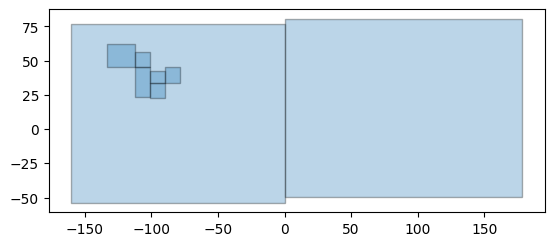

In [11]:
ddf.spatial_partitions.plot(edgecolor='k', alpha=0.3)

# Upload to COS and register in STAC

In [12]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('claimed_access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('claimed_secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('claimed_endpoint_url', '')
# S3 access url
private_endpoint_url = os.getenv('claimed_private_endpoint_url', '')
# S3 bucket
bucket = os.getenv('claimed_bucket', '')

# STAC url
stac_url = os.getenv('stac_url', 'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com')
# STAC certificate
certificate = os.getenv('certificate', '/opt/app-root/src/ca.cert.txt')

#vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

In [13]:
# vs.access_key_id = access_key_id
# vs.secret_access_key = secret_access_key
# vs.endpoint_url = endpoint_url
# vs.bucket = bucket
# vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

# storage_urls = vs.remote_fs.glob(os.path.join(vs.remote_geoparquet_directory, '**.parquet').replace('\\', '/'))
# storage_urls

In [14]:
# # GeoDN username
# geodn_username = os.getenv('geodn_username', '')
# # GeoDN password
# geodn_password = os.getenv('geodn_password', '')
# # GeoDN url
# GEODN_URL = os.getenv('GEODN_URL', "https://openeo-geodn-nasageospatial-dev.cash.sl.cloud9.ibm.com/openeo/1.1.0/")

In [15]:
stac_json_folder = os.path.join(vs.grid_directory, 'stac').replace('\\','/')

bbox = vs.grid.valid_bounds_wgs84
df = pandas.read_parquet(vs.geoparquet_directory, columns=[vs.dt_col])
dt_start = df[vs.dt_col].min()
dt_end = df[vs.dt_col].max()

vs.to_stac_collection(
    stac_url,
    vs.collection_id,
    collection_title,
    stac_json_folder,
    certificate,
    bbox,
    dt_start,
    dt_end,
    description,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
)

In [16]:
%%time
# Upload to COS
upload_type = "replace_all" #"replace_all" "replace_partition" "add" "stac_items_only"
vs.to_cos(
    upload_type=upload_type,
    stac_url=stac_url,
    collection_id=vs.collection_id,
    collection_title=collection_title,
    stac_json_folder=stac_json_folder,
    certificate=certificate,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
    temporal_partitions=None,
    spatial_partitions=None,
)

uploading to remote_path claimed-test/vectorstore/oil_gas_infrastructure_mapping/grid=World(4326)/geoparquet/spatial_partition=0q0/af0c79df70154eed9dcff62242a9809d.parquet
schema.names ['OGIM_ID', 'CATEGORY', 'REGION', 'COUNTRY', 'STATE_PROV', 'SRC_REF_ID', 'SRC_DATE', 'ON_OFFSHORE', 'FAC_NAME', 'FAC_ID', 'FAC_TYPE', 'DRILL_TYPE', 'SPUD_DATE', 'COMP_DATE', 'FAC_STATUS', 'OGIM_STATUS', 'OPERATOR', 'LATITUDE', 'LONGITUDE', 'ATTRIBUTE_SCORE', 'DATA_SOURCE_SCORE', 'UPDATE_FREQUENCY_SCORE', 'AGGREGATE_QUALITY_SCORE', 'geometry', 'timestamp_completed', '_root']
schema.types [DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(double), DataType(double), DataType(int64), DataType(double), DataType(int64), DataType(double), DataType(bin

In [17]:
vs.stac_json_folder_submitted

'data/vectorstore/oil_gas_infrastructure_mapping/grid=World(4326)/stac/submitted'

In [18]:
vs.stac_url

'https://stac-fastapi-sqlalchemy-nasageospatial-dev.cash.sl.cloud9.ibm.com'

In [19]:
vs.collection_id

'vector-oil-gas-infrastructure-mapping'